In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

d:\LangGraph\Sequential Workflows\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

True

In [3]:
llm = HuggingFaceEndpoint(
  repo_id="Qwen/Qwen3-Coder-Next",
  task='text-generation'
)

model = ChatHuggingFace(llm=llm)

d:\LangGraph\Sequential Workflows\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class JokeState(TypedDict):
  topic: str
  joke:str
  explaination: str
  

In [4]:
def generate_joke(state: JokeState):
  prompt = f'Generate a joke on {state['topic']}'
  joke = model.invoke(prompt).content
  
  return {'joke':joke}
  

In [5]:
def explain_joke(state: JokeState):
  joke = state['joke']
  prompt = f'explain the following joke: {joke}'
  
  explaination = model.invoke(prompt).content
  
  return {"explaination":explaination}

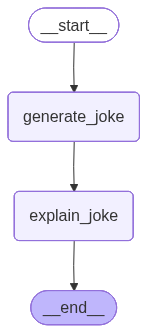

In [9]:
checkpointer = MemorySaver()
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("generate_joke", END)

workflow= graph.compile(checkpointer=checkpointer)
workflow

In [11]:
config1 = {"configurable": {"thread_id":"1"}}

workflow.invoke({"topic":"Engineer"}, config=config1)

{'topic': 'Engineer',
 'joke': "Sure! Here's a classic engineering-style joke with a side of irony:\n\n> **An engineer, a physicist, and a mathematician are staying in a hotel.**  \n> That night, the engineer’s room catches fire. He grabs a fire extinguisher, puts out the flames, and goes back to sleep.  \n> Later, the physicist’s room catches fire. He carefully calculates the optimal extinguishing angle, flow rate, and fuel type—then douses the fire with minimal effort.  \n> Finally, the mathematician’s room bursts into flames. He looks at the fire, thinks for a moment, and exclaims:  \n>   \n> **“A solution exists!”**  \n> *Then he goes back to bed.*  \n\n😄  \n*Why engineers love it:* It’s not about solving the fire—it’s about *proving* the problem is solvable. (And maybe hoping someone else handles it.)\n\nWant a specific type—civil, software, mechanical, or even a *dad-joke* engineer? Just say the word!",
 'explaination': 'This is a brilliant and classic *disciplinary stereotype* j

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Engineer', 'joke': "Sure! Here's a classic engineering-style joke with a side of irony:\n\n> **An engineer, a physicist, and a mathematician are staying in a hotel.**  \n> That night, the engineer’s room catches fire. He grabs a fire extinguisher, puts out the flames, and goes back to sleep.  \n> Later, the physicist’s room catches fire. He carefully calculates the optimal extinguishing angle, flow rate, and fuel type—then douses the fire with minimal effort.  \n> Finally, the mathematician’s room bursts into flames. He looks at the fire, thinks for a moment, and exclaims:  \n>   \n> **“A solution exists!”**  \n> *Then he goes back to bed.*  \n\n😄  \n*Why engineers love it:* It’s not about solving the fire—it’s about *proving* the problem is solvable. (And maybe hoping someone else handles it.)\n\nWant a specific type—civil, software, mechanical, or even a *dad-joke* engineer? Just say the word!", 'explaination': 'This is a brilliant and classic *discipl

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Engineer', 'joke': "Sure! Here's a classic engineering-style joke with a side of irony:\n\n> **An engineer, a physicist, and a mathematician are staying in a hotel.**  \n> That night, the engineer’s room catches fire. He grabs a fire extinguisher, puts out the flames, and goes back to sleep.  \n> Later, the physicist’s room catches fire. He carefully calculates the optimal extinguishing angle, flow rate, and fuel type—then douses the fire with minimal effort.  \n> Finally, the mathematician’s room bursts into flames. He looks at the fire, thinks for a moment, and exclaims:  \n>   \n> **“A solution exists!”**  \n> *Then he goes back to bed.*  \n\n😄  \n*Why engineers love it:* It’s not about solving the fire—it’s about *proving* the problem is solvable. (And maybe hoping someone else handles it.)\n\nWant a specific type—civil, software, mechanical, or even a *dad-joke* engineer? Just say the word!", 'explaination': 'This is a brilliant and classic *discip